In [1]:
import qbiome
from qbiome.data_formatter import DataFormatter
from qbiome.quantizer import Quantizer
from qbiome.qnet_orchestrator import QnetOrchestrator
from qbiome.forecaster import Forecaster
from qbiome.hypothesis import Hypothesis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("fivethirtyeight")
from qbiome.qutil import qsmooth

In [2]:
# File path to your merged CSV file
file_path = "example_data/training_data_weeks_60_to_90_sewage_timeseries.csv"  # update with actual path if needed

# Read the CSV into a DataFrame
merged_df = pd.read_csv(file_path,keep_default_na=False)

# Preview the first few rows
print(merged_df.head())

   sample_id     Site          taxa_id  rel_abundance      COLLECTION_DATE  \
0  1014220_1  Bologna       Acidovorax       0.151028  2020-04-07 00:00:00   
1  1014220_1  Bologna    Acinetobacter       0.017902  2020-04-07 00:00:00   
2  1014220_1  Bologna        Aeromonas       0.004478  2020-04-07 00:00:00   
3  1014220_1  Bologna    Aliarcobacter       0.006025  2020-04-07 00:00:00   
4  1014220_1  Bologna  Aquabacterium_A       0.067315  2020-04-07 00:00:00   

                               COMPLETE_NAME COUNTRY     CITY  LATITUDE  \
0  DTU_2022_1014220_1_MG_IT_BO_200407_GSL_60   Italy  Bologna   44.4949   
1  DTU_2022_1014220_1_MG_IT_BO_200407_GSL_60   Italy  Bologna   44.4949   
2  DTU_2022_1014220_1_MG_IT_BO_200407_GSL_60   Italy  Bologna   44.4949   
3  DTU_2022_1014220_1_MG_IT_BO_200407_GSL_60   Italy  Bologna   44.4949   
4  DTU_2022_1014220_1_MG_IT_BO_200407_GSL_60   Italy  Bologna   44.4949   

   LONGITUDE        PLANT  relative_week  
0    11.3426  Gruppo HERA            

In [3]:
merged_df = merged_df[merged_df['taxa_id'] != 'merged']

In [4]:
# Select the desired columns
data = merged_df[['sample_id', 'Site', 'taxa_id', 'rel_abundance', 'relative_week']].copy()

# Rename the columns
data.rename(columns={
    'Site': 'subject_id',
    'taxa_id': 'variable',
    'rel_abundance': 'value',
    'relative_week': 'week'
}, inplace=True)
df = pd.DataFrame(data)
df.to_csv('europe_data.csv', index=False)

# Preview the result
print(data.head())

   sample_id subject_id         variable     value  week
0  1014220_1    Bologna       Acidovorax  0.151028    61
1  1014220_1    Bologna    Acinetobacter  0.017902    61
2  1014220_1    Bologna        Aeromonas  0.004478    61
3  1014220_1    Bologna    Aliarcobacter  0.006025    61
4  1014220_1    Bologna  Aquabacterium_A  0.067315    61


In [5]:
print(data.variable.unique())

['Acidovorax' 'Acinetobacter' 'Aeromonas' 'Aliarcobacter'
 'Aquabacterium_A' 'Bacteroides' 'Brachymonas' 'Brevefilum'
 'Brevundimonas' 'Cloacibacterium' 'Comamonas' 'Competibacter_A'
 'Enterobacter' 'Fermentibacter' 'Flavobacterium' 'Giesbergeria'
 'Hydrogenophaga' 'JAGOYM01' 'Janthinobacterium' 'Kaistella'
 'Lactococcus_A' 'Lenti-01' 'Microthrix' 'Moraxella_A' 'Neisseria'
 'Novosphingobium' 'Ottowia' 'Paracoccus' 'Phocaeicola' 'Prevotella'
 'Propionivibrio' 'Pseudomonas_E' 'Pseudoxanthomonas'
 'Pseudoxanthomonas_A' 'Psychrobacter' 'Rubrivivax' 'Streptococcus'
 'Telluria' 'Thauera' 'Thermomonas' 'Thiothrix' 'Tolumonas' 'Trichococcus'
 'UBA1413']


In [6]:
# week_91_100_entries = []
# for week in range(91, 101):  # future weeks
#     for subject in data['subject_id'].unique():
#         for var in data['variable'].unique():
#             week_91_100_entries.append({
#                 'sample_id': f"{subject}_dummy{week}",  # distinguish dummy entries
#                 'subject_id': subject,
#                 'variable': var,
#                 'value': np.nan,   # ⛳ Leave as NaN for proper masking
#                 'week': week
#             })

# future_df = pd.DataFrame(week_91_100_entries)


In [7]:
# import numpy as np

# rng = np.random.default_rng(42)                         # fixed seed for reproducibility
# nan_mask = future_df["value"].isna()                         # rows where value is NaN
# future_df.loc[nan_mask, "value"] = rng.uniform(1e-6, 1e-4, nan_mask.sum())

In [8]:
# data = pd.concat([data, future_df], ignore_index=True)

In [9]:
data

,sample_id,subject_id,variable,value,week
0,1014220_1,Bologna,Acidovorax,0.151028,61
1,1014220_1,Bologna,Acinetobacter,0.017902,61
2,1014220_1,Bologna,Aeromonas,0.004478,61
3,1014220_1,Bologna,Aliarcobacter,0.006025,61
4,1014220_1,Bologna,Aquabacterium_A,0.067315,61
...,...,...,...,...,...
5169,1014166_1,Rotterdam,Thermomonas,0.010926,90
5170,1014166_1,Rotterdam,Thiothrix,0.004042,90
5171,1014166_1,Rotterdam,Tolumonas,0.026276,90
5172,1014166_1,Rotterdam,Trichococcus,0.003335,90


In [10]:
len(data.variable.unique())

44

In [11]:
data.week.unique()

array([61, 63, 65, 67, 69, 72, 75, 77, 79, 81, 83, 85, 88, 89, 68, 73, 74,
       78, 80, 84, 87, 90, 60, 64, 70, 71, 82, 86, 62, 66])

In [12]:
base_tax = "Time_Series_Sewage_time_split"

In [13]:
biome=data.variable.values[1]
biome

'Acinetobacter'

In [14]:
quantizer = Quantizer(num_levels=26)
qnet_orchestrator = QnetOrchestrator(quantizer)
quantized = quantizer.quantize_df(data)


In [15]:
data.variable.unique()

array(['Acidovorax', 'Acinetobacter', 'Aeromonas', 'Aliarcobacter',
       'Aquabacterium_A', 'Bacteroides', 'Brachymonas', 'Brevefilum',
       'Brevundimonas', 'Cloacibacterium', 'Comamonas', 'Competibacter_A',
       'Enterobacter', 'Fermentibacter', 'Flavobacterium', 'Giesbergeria',
       'Hydrogenophaga', 'JAGOYM01', 'Janthinobacterium', 'Kaistella',
       'Lactococcus_A', 'Lenti-01', 'Microthrix', 'Moraxella_A',
       'Neisseria', 'Novosphingobium', 'Ottowia', 'Paracoccus',
       'Phocaeicola', 'Prevotella', 'Propionivibrio', 'Pseudomonas_E',
       'Pseudoxanthomonas', 'Pseudoxanthomonas_A', 'Psychrobacter',
       'Rubrivivax', 'Streptococcus', 'Telluria', 'Thauera',
       'Thermomonas', 'Thiothrix', 'Tolumonas', 'Trichococcus', 'UBA1413'],
      dtype=object)

In [16]:
quantized

,subject_id,Acidovorax_60,Acidovorax_61,Acidovorax_62,Acidovorax_63,Acidovorax_64,Acidovorax_65,Acidovorax_66,Acidovorax_67,Acidovorax_68,...,UBA1413_81,UBA1413_82,UBA1413_83,UBA1413_84,UBA1413_85,UBA1413_86,UBA1413_87,UBA1413_88,UBA1413_89,UBA1413_90
0,Bologna,NaN,Y,NaN,Q,NaN,Z,NaN,Y,NaN,...,Z,NaN,A,NaN,A,NaN,NaN,A,M,NaN
1,Budapest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,A,...,NaN,NaN,A,M,NaN,NaN,Z,NaN,NaN,L
2,Copenaghen_RA,NaN,A,NaN,NaN,T,A,NaN,N,P,...,D,I,NaN,NaN,NaN,B,NaN,NaN,NaN,NaN
3,Copenaghen_RD,A,C,NaN,NaN,U,J,NaN,Z,G,...,NaN,Z,NaN,NaN,NaN,I,NaN,NaN,NaN,NaN
4,Copenaghen_RL,Z,Z,NaN,A,Z,S,NaN,Z,N,...,A,J,NaN,NaN,NaN,Z,NaN,NaN,NaN,NaN
5,Rome,R,NaN,Z,Z,NaN,NaN,M,NaN,Z,...,NaN,A,Z,NaN,Z,NaN,A,NaN,NaN,Z
6,Rotterdam,NaN,NaN,A,NaN,A,Q,NaN,NaN,A,...,A,NaN,A,NaN,NaN,A,NaN,Z,NaN,A


In [17]:
# genus_list = ['Acidovorax', 'Acinetobacter', 'Aeromonas', 'Aliarcobacter',
#        'Aquabacterium_A', 'Bacteroides', 'Brachymonas', 'Brevefilum',
#        'Brevundimonas', 'Cloacibacterium', 'Comamonas', 'Competibacter_A',
#        'Enterobacter', 'Fermentibacter', 'Flavobacterium', 'Giesbergeria',
#        'Hydrogenophaga', 'JAGOYM01', 'Janthinobacterium', 'Kaistella',
#        'Lactococcus_A', 'Lenti-01', 'Microthrix', 'Moraxella_A',
#        'Neisseria', 'Novosphingobium', 'Ottowia', 'Paracoccus',
#        'Phocaeicola', 'Prevotella', 'Propionivibrio', 'Pseudomonas_E',
#        'Pseudoxanthomonas', 'Pseudoxanthomonas_A', 'Psychrobacter',
#        'Rubrivivax', 'Streptococcus', 'Telluria', 'Thauera',
#        'Thermomonas', 'Thiothrix', 'Tolumonas', 'Trichococcus', 'UBA1413'] 

In [18]:
# days = range(91, 111)   # 91 through 110 inclusive

# # 3️⃣  Append blank columns to *quantized* for every genus × day
# for genus in genus_list:
#     for d in days:
#         quantized[f"{genus}_{d}"] = np.nan

In [19]:
quantized

,subject_id,Acidovorax_60,Acidovorax_61,Acidovorax_62,Acidovorax_63,Acidovorax_64,Acidovorax_65,Acidovorax_66,Acidovorax_67,Acidovorax_68,...,UBA1413_81,UBA1413_82,UBA1413_83,UBA1413_84,UBA1413_85,UBA1413_86,UBA1413_87,UBA1413_88,UBA1413_89,UBA1413_90
0,Bologna,NaN,Y,NaN,Q,NaN,Z,NaN,Y,NaN,...,Z,NaN,A,NaN,A,NaN,NaN,A,M,NaN
1,Budapest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,A,...,NaN,NaN,A,M,NaN,NaN,Z,NaN,NaN,L
2,Copenaghen_RA,NaN,A,NaN,NaN,T,A,NaN,N,P,...,D,I,NaN,NaN,NaN,B,NaN,NaN,NaN,NaN
3,Copenaghen_RD,A,C,NaN,NaN,U,J,NaN,Z,G,...,NaN,Z,NaN,NaN,NaN,I,NaN,NaN,NaN,NaN
4,Copenaghen_RL,Z,Z,NaN,A,Z,S,NaN,Z,N,...,A,J,NaN,NaN,NaN,Z,NaN,NaN,NaN,NaN
5,Rome,R,NaN,Z,Z,NaN,NaN,M,NaN,Z,...,NaN,A,Z,NaN,Z,NaN,A,NaN,NaN,Z
6,Rotterdam,NaN,NaN,A,NaN,A,Q,NaN,NaN,A,...,A,NaN,A,NaN,NaN,A,NaN,Z,NaN,A


In [20]:
features, label_matrix = quantizer.get_qnet_inputs(quantized)

In [21]:
display(features)
display(label_matrix)

Index(['Acidovorax_60', 'Acidovorax_61', 'Acidovorax_62', 'Acidovorax_63',
       'Acidovorax_64', 'Acidovorax_65', 'Acidovorax_66', 'Acidovorax_67',
       'Acidovorax_68', 'Acidovorax_69',
       ...
       'UBA1413_81', 'UBA1413_82', 'UBA1413_83', 'UBA1413_84', 'UBA1413_85',
       'UBA1413_86', 'UBA1413_87', 'UBA1413_88', 'UBA1413_89', 'UBA1413_90'],
      dtype='object', length=1320)

array([['', 'Y', '', ..., 'A', 'M', ''],
       ['', '', '', ..., '', '', 'L'],
       ['', 'A', '', ..., '', '', ''],
       ...,
       ['Z', 'Z', '', ..., '', '', ''],
       ['R', '', 'Z', ..., '', '', 'Z'],
       ['', '', 'A', ..., 'Z', '', 'A']], dtype='<U1')

In [22]:
features

Index(['Acidovorax_60', 'Acidovorax_61', 'Acidovorax_62', 'Acidovorax_63',
       'Acidovorax_64', 'Acidovorax_65', 'Acidovorax_66', 'Acidovorax_67',
       'Acidovorax_68', 'Acidovorax_69',
       ...
       'UBA1413_81', 'UBA1413_82', 'UBA1413_83', 'UBA1413_84', 'UBA1413_85',
       'UBA1413_86', 'UBA1413_87', 'UBA1413_88', 'UBA1413_89', 'UBA1413_90'],
      dtype='object', length=1320)

In [23]:
label_matrix.shape

(7, 1320)

In [24]:
TAXA = list(data.variable.value_counts().index.values)
TAXA

['Acidovorax',
 'Acinetobacter',
 'Aeromonas',
 'Aliarcobacter',
 'Aquabacterium_A',
 'Bacteroides',
 'Brachymonas',
 'Brevefilum',
 'Brevundimonas',
 'Cloacibacterium',
 'Comamonas',
 'Competibacter_A',
 'Enterobacter',
 'Fermentibacter',
 'Flavobacterium',
 'Giesbergeria',
 'Hydrogenophaga',
 'JAGOYM01',
 'Janthinobacterium',
 'Kaistella',
 'Lactococcus_A',
 'Lenti-01',
 'Microthrix',
 'Moraxella_A',
 'Neisseria',
 'Novosphingobium',
 'Ottowia',
 'Paracoccus',
 'Phocaeicola',
 'Prevotella',
 'Propionivibrio',
 'Pseudomonas_E',
 'Pseudoxanthomonas',
 'Pseudoxanthomonas_A',
 'Psychrobacter',
 'Rubrivivax',
 'Streptococcus',
 'Telluria',
 'Thauera',
 'Thermomonas',
 'Thiothrix',
 'Tolumonas',
 'Trichococcus',
 'UBA1413']

In [24]:
%%time
qnet_orchestrator.train_qnet(
    features, label_matrix, alpha=0.3, min_samples_split=2, out_fname=None
)


CPU times: user 23.3 s, sys: 676 ms, total: 24 s
Wall time: 32.9 s


In [25]:
%%time
qnet_orchestrator.save_qnet("example_qnet_"+base_tax+".pkl",GZIP=True)

CPU times: user 4min 10s, sys: 2.71 s, total: 4min 12s
Wall time: 4min 12s


In [26]:
print("hello")

hello


In [25]:
from quasinet.qnet import load_qnet
outdirname = 'trees_'+base_tax
modelpath="example_qnet_"+base_tax+".pkl.gz"
model=load_qnet(modelpath,gz=True)
model.viz_trees(tree_path=outdirname,big_enough_threshold=1,format='png',
                remove_newline=True,remove_dotfile=True)

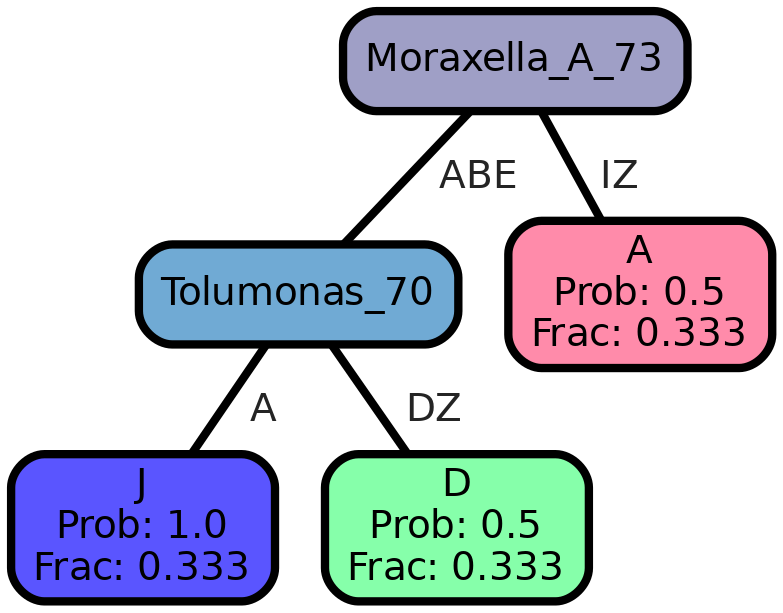

In [79]:
from IPython.display import Image
import glob
Image(filename=glob.glob(outdirname+"/*png")[2])

### Inspect Positive and Negative Regulation (LOMAR coefficients)

In [62]:
# qnet_orchestrator.load_qnet("example_qnet_"+base_tax+".pkl.gz",GZIP=True)
hypothesis = Hypothesis(
    quantizer=quantizer,qnet_orchestrator=qnet_orchestrator, detailed_labels=True
)

In [63]:
hypothesis.causal_constraint = -2
hypothesis.no_self_loops = False

hypothesis.get(time_start=60, time_end=90)
hypothesis.to_dot("hypothesis_1_10.dot")
hypothesis.hypotheses.sort_values("src")

100%|██████████| 44/44 [00:23<00:00,  1.85it/s]


,src,tgt,time_tgt,lomar,pvalue
58,Acidovorax,Giesbergeria,74.0,0.252041,0.0
260,Acinetobacter,Psychrobacter,80.0,0.150545,0.0
134,Acinetobacter,Cloacibacterium,81.0,0.343097,0.0
224,Aeromonas,Neisseria,78.0,1.606888,0.0
89,Aeromonas,Hydrogenophaga,68.0,0.106144,0.0
...,...,...,...,...,...
80,UBA1413,Tolumonas,80.0,52.746826,0.0
161,UBA1413,Lactococcus_A,65.0,17978.857875,0.0
144,UBA1413,Rubrivivax,80.0,1.483143,0.0
235,UBA1413,Acinetobacter,77.0,6093.538208,0.0


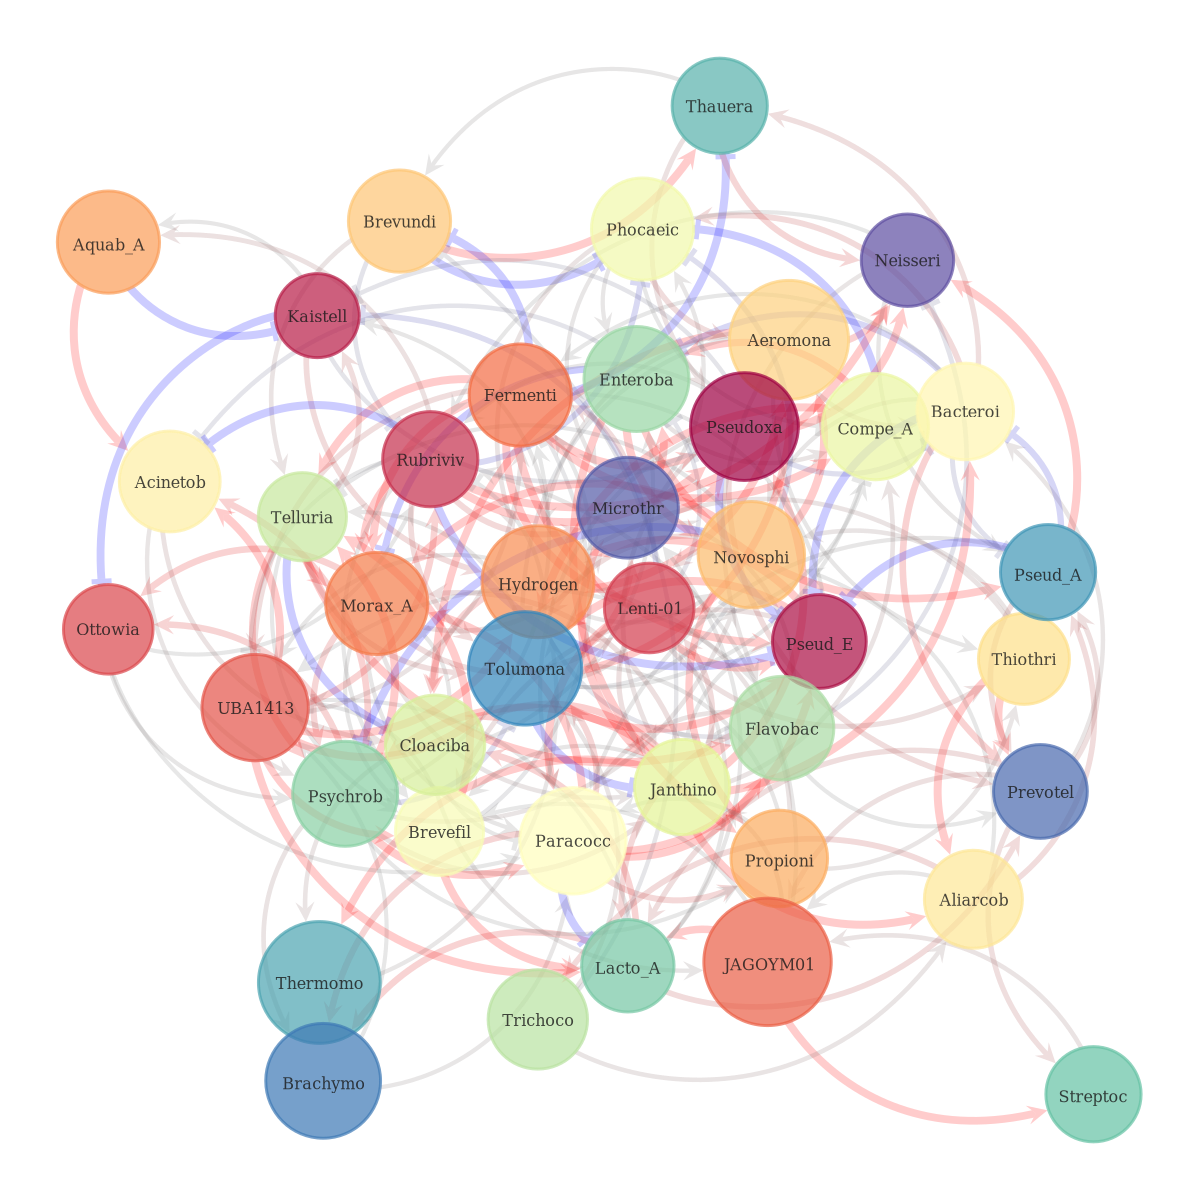

In [64]:
# # if graph-tool is installed
from qbiome.network import Network
Network('hypothesis_1_10.dot',outfile='net.png').get()
# Can also use the external prog
#! python3.7 plotNetwork.py >& /dev/null
from IPython.display import Image
Image(filename='net.png')

### Forecast microbiome evolutionary trajectories

In [26]:
# qnet_orchestrator.load_qnet("example_qnet_"+base_tax+".pkl.gz",GZIP=True)

# --- Step 6: Load trained Q-net model ---
qnet_orchestrator = QnetOrchestrator(quantizer)
qnet_orchestrator.load_qnet("example_qnet_" + base_tax + ".pkl.gz", GZIP=True)


In [20]:
quantized

,subject_id,Acidovorax_60,Acidovorax_61,Acidovorax_62,Acidovorax_63,Acidovorax_64,Acidovorax_65,Acidovorax_66,Acidovorax_67,Acidovorax_68,...,UBA1413_81,UBA1413_82,UBA1413_83,UBA1413_84,UBA1413_85,UBA1413_86,UBA1413_87,UBA1413_88,UBA1413_89,UBA1413_90
0,Bologna,NaN,Y,NaN,Q,NaN,Z,NaN,Y,NaN,...,Z,NaN,A,NaN,A,NaN,NaN,A,M,NaN
1,Budapest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,A,...,NaN,NaN,A,M,NaN,NaN,Z,NaN,NaN,L
2,Copenaghen_RA,NaN,A,NaN,NaN,T,A,NaN,N,P,...,D,I,NaN,NaN,NaN,B,NaN,NaN,NaN,NaN
3,Copenaghen_RD,A,C,NaN,NaN,U,J,NaN,Z,G,...,NaN,Z,NaN,NaN,NaN,I,NaN,NaN,NaN,NaN
4,Copenaghen_RL,Z,Z,NaN,A,Z,S,NaN,Z,N,...,A,J,NaN,NaN,NaN,Z,NaN,NaN,NaN,NaN
5,Rome,R,NaN,Z,Z,NaN,NaN,M,NaN,Z,...,NaN,A,Z,NaN,Z,NaN,A,NaN,NaN,Z
6,Rotterdam,NaN,NaN,A,NaN,A,Q,NaN,NaN,A,...,A,NaN,A,NaN,NaN,A,NaN,Z,NaN,A


In [27]:
SW = 70
EW = 90
#qnet_orchestrator = QnetOrchestrator(quantizer)
#qnet_orchestrator.load_qnet("example_qnet.pkl.gz",GZIP=True)
forecaster = Forecaster(qnet_orchestrator)
# can specify an end week or default to the max end week in the data
forecasted_ = forecaster.forecast_data(label_matrix, start_week=SW, end_week=EW).assign(
    source="forecasted"
)

In [28]:
forecasted_.week.unique()

array([60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 77,
       78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90])

In [29]:
biome=data.variable.values[3]
biome

'Aliarcobacter'

In [30]:
DF = forecasted_
SUBJECTS = DF.subject_id.value_counts().index.values
DF

DF_pop = DF.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()
DF_data = data.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()

In [31]:
DF_data

,variable,week,value
0,Acidovorax,60,1.993992e-01
1,Acidovorax,61,1.288493e-01
2,Acidovorax,62,1.863044e-01
3,Acidovorax,63,1.847429e-01
4,Acidovorax,64,1.680323e-01
...,...,...,...
1315,UBA1413,86,1.385940e-04
1316,UBA1413,87,9.944855e-07
1317,UBA1413,88,9.236880e-07
1318,UBA1413,89,5.786940e-08


In [32]:
SUBJECTS

array(['Bologna', 'Budapest', 'Copenaghen_RA', 'Copenaghen_RD',
       'Copenaghen_RL', 'Rome', 'Rotterdam'], dtype=object)

In [33]:
DF.week.unique()

array([60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 77,
       78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90])

In [34]:
DF

,subject_id,variable,week,value,source
0,Bologna,Acidovorax,60,NaN,forecasted
1,Budapest,Acidovorax,60,NaN,forecasted
2,Copenaghen_RA,Acidovorax,60,NaN,forecasted
3,Copenaghen_RD,Acidovorax,60,0.168080,forecasted
4,Copenaghen_RL,Acidovorax,60,0.224277,forecasted
...,...,...,...,...,...
9235,Copenaghen_RA,UBA1413,90,0.000007,forecasted
9236,Copenaghen_RD,UBA1413,90,0.000008,forecasted
9237,Copenaghen_RL,UBA1413,90,0.000007,forecasted
9238,Rome,UBA1413,90,0.000006,forecasted


In [35]:
data

,sample_id,subject_id,variable,value,week
0,1014220_1,Bologna,Acidovorax,0.151028,61
1,1014220_1,Bologna,Acinetobacter,0.017902,61
2,1014220_1,Bologna,Aeromonas,0.004478,61
3,1014220_1,Bologna,Aliarcobacter,0.006025,61
4,1014220_1,Bologna,Aquabacterium_A,0.067315,61
...,...,...,...,...,...
5169,1014166_1,Rotterdam,Thermomonas,0.010926,90
5170,1014166_1,Rotterdam,Thiothrix,0.004042,90
5171,1014166_1,Rotterdam,Tolumonas,0.026276,90
5172,1014166_1,Rotterdam,Trichococcus,0.003335,90


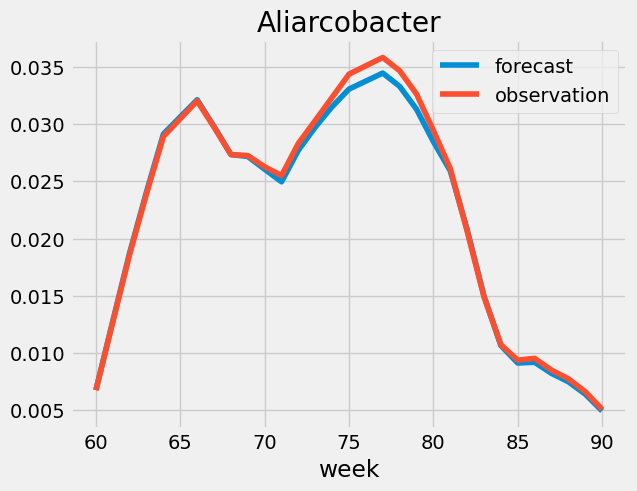

In [36]:
DF_pop = DF.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()
DF_data = data.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()

DF_pop_smooth = qsmooth(
    DF_pop,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.3,
)

# DF_data_smooth
DF_data_smooth = qsmooth(
    DF_data,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.3,
)

ax = DF_pop_smooth[biome].plot(label="forecast")
DF_data_smooth[biome].plot(ax=ax, label="observation")
ax.set_title(biome)
ax.legend()

In [37]:
DF_pop

,variable,week,value
0,Acidovorax,60,1.995536e-01
1,Acidovorax,61,1.288473e-01
2,Acidovorax,62,1.862698e-01
3,Acidovorax,63,1.852192e-01
4,Acidovorax,64,1.676121e-01
...,...,...,...
1315,UBA1413,86,1.358718e-04
1316,UBA1413,87,1.034418e-06
1317,UBA1413,88,9.044110e-07
1318,UBA1413,89,5.786717e-08


In [38]:
week_90_DF = DF_pop[DF_pop['week'] == 90]
week_90_DF

,variable,week,value
29,Acidovorax,90,0.163635
59,Acinetobacter,90,0.046094
89,Aeromonas,90,0.011003
119,Aliarcobacter,90,0.005906
149,Aquabacterium_A,90,0.001199
179,Bacteroides,90,0.001588
209,Brachymonas,90,0.016357
239,Brevefilum,90,0.000005
269,Brevundimonas,90,0.003501
299,Cloacibacterium,90,0.008079


In [39]:

week_90_data = DF_data[DF_data['week'] == 90]
week_90_data

,variable,week,value
29,Acidovorax,90,0.166602
59,Acinetobacter,90,0.044779
89,Aeromonas,90,0.011584
119,Aliarcobacter,90,0.005913
149,Aquabacterium_A,90,0.001291
179,Bacteroides,90,0.001619
209,Brachymonas,90,0.016416
239,Brevefilum,90,0.000005
269,Brevundimonas,90,0.003475
299,Cloacibacterium,90,0.008037


In [40]:
merged_week_90 = pd.merge(
    week_90_DF,
    week_90_data,
    on='variable',
    suffixes=('_pop', '_data')
)

# Display merged DataFrame
merged_week_90.to_csv('merged_week_90.csv')

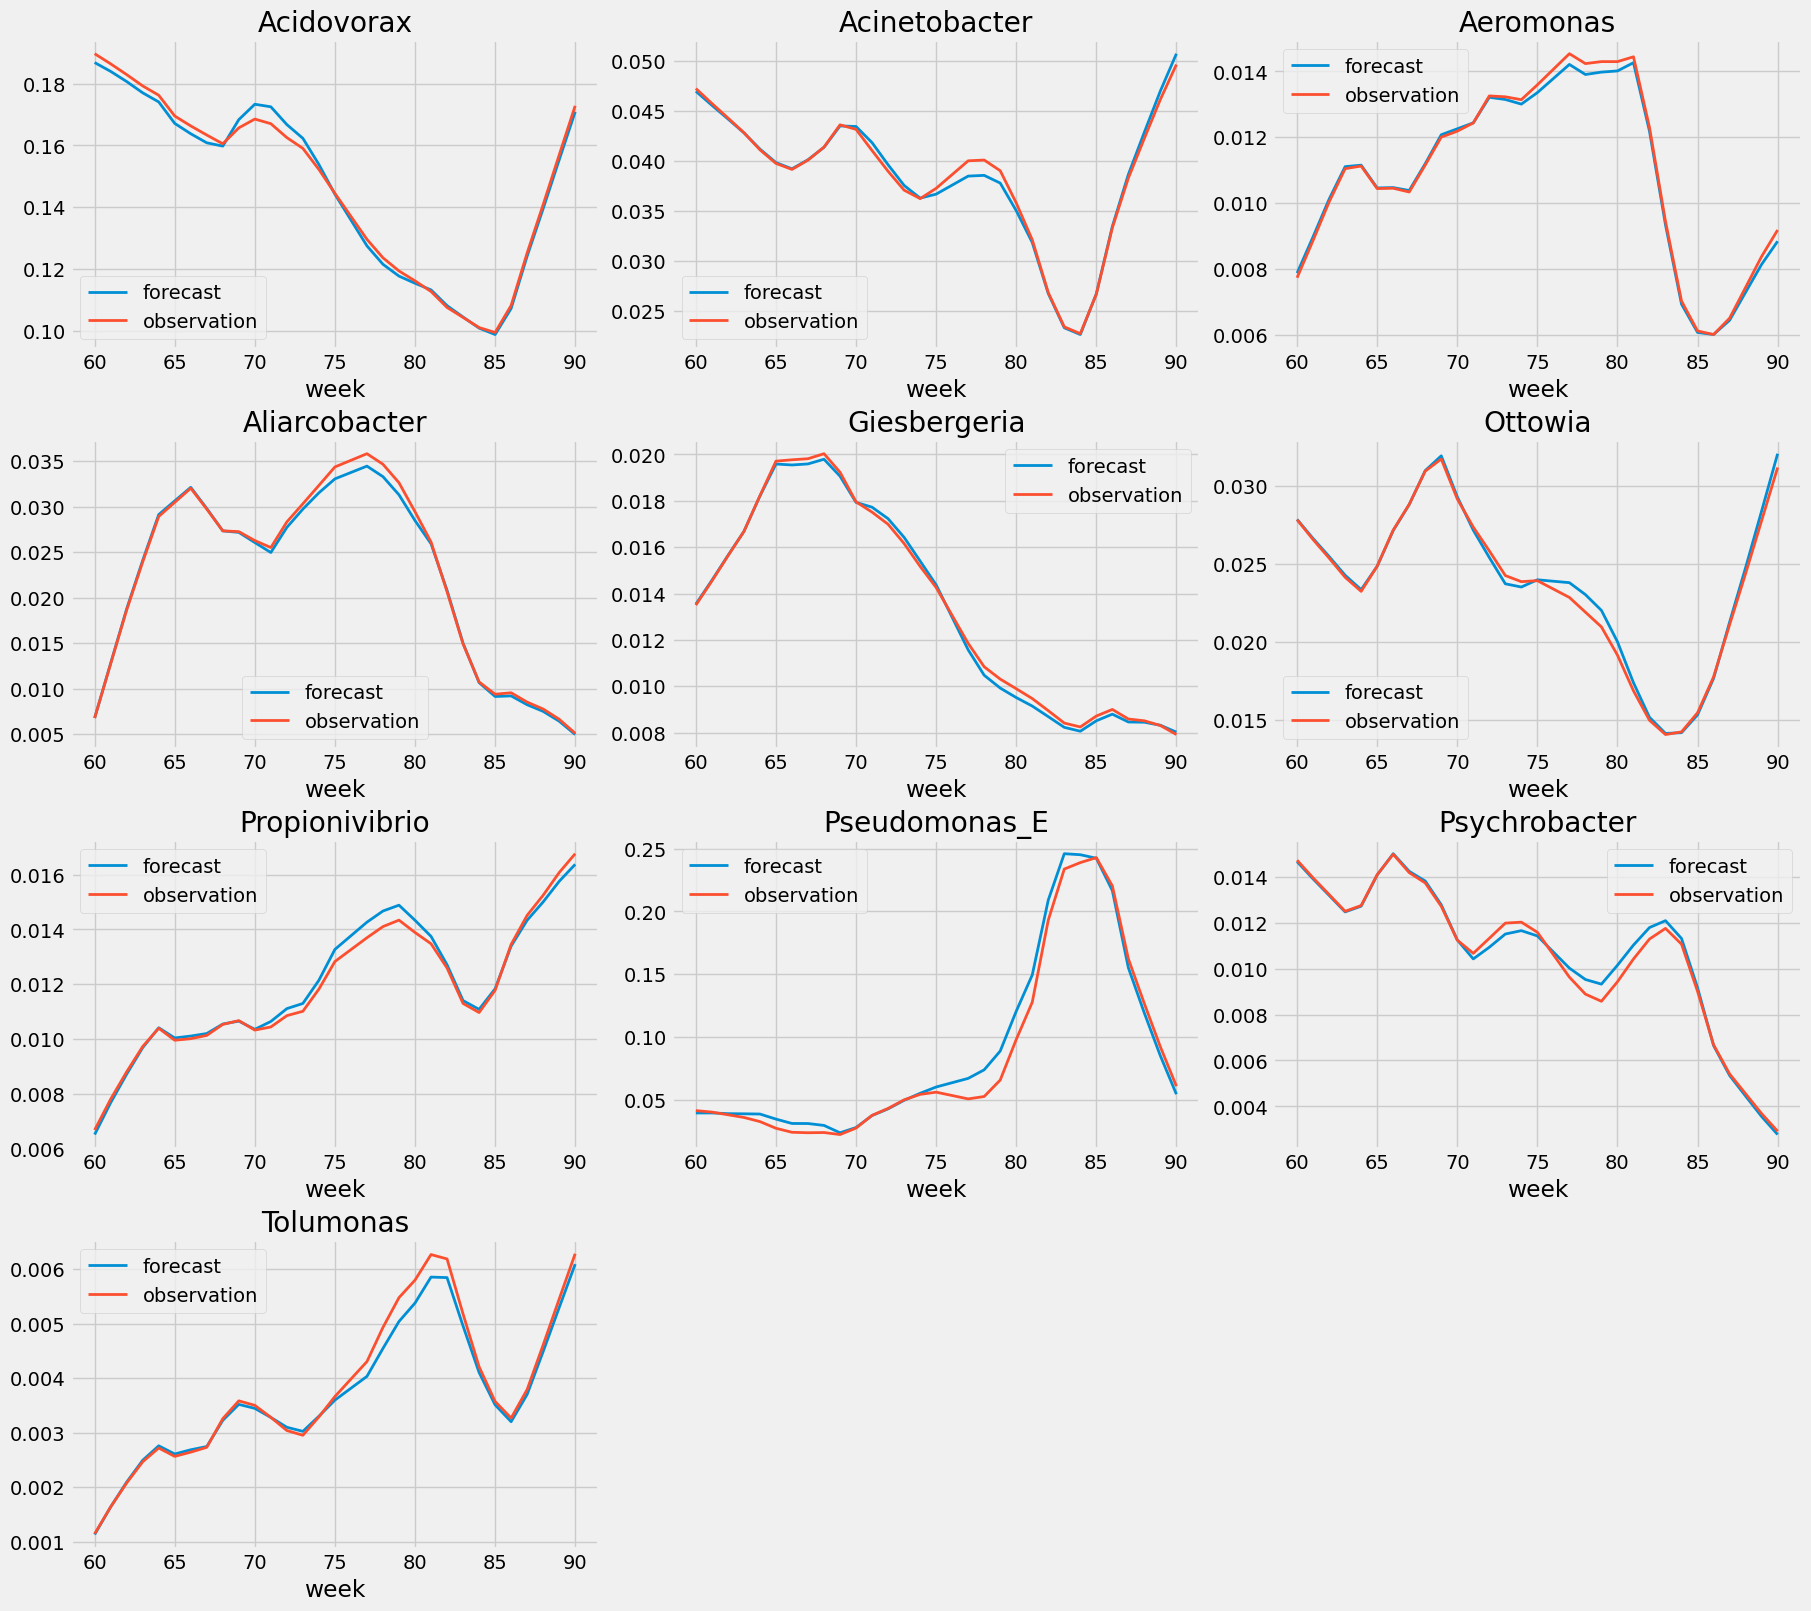

In [41]:
import matplotlib.pyplot as plt

# List of taxa (biomes)
taxa = [
    "Acidovorax", "Acinetobacter", "Aeromonas", "Aliarcobacter", "Giesbergeria",
    "Ottowia", "Propionivibrio", "Pseudomonas_E", "Psychrobacter", "Tolumonas"
]

# Set number of columns
ncols = 3
nrows = (len(taxa) + ncols - 1) // ncols  # Ceiling division

# Create subplots
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4), constrained_layout=True)
axs = axs.flatten()


DF_pop_smooth = qsmooth(
    DF_pop,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.3,
)

# DF_data_smooth
DF_data_smooth = qsmooth(
    DF_data,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.3,
)
# Plot each biome
for i, biome in enumerate(taxa):
    ax = axs[i]
    DF_pop_smooth[biome].plot(ax=ax, label="forecast", linewidth=2)
    DF_data_smooth[biome].plot(ax=ax, label="observation", linewidth=2)
    ax.set_title(biome)
    ax.legend()

# Hide unused subplots
for j in range(len(taxa), len(axs)):
    fig.delaxes(axs[j])

plt.show()


In [42]:
DF_data_smooth

,Acidovorax,Acinetobacter,Aeromonas,Aliarcobacter,Aquabacterium_A,Bacteroides,Brachymonas,Brevefilum,Brevundimonas,Cloacibacterium,...,Psychrobacter,Rubrivivax,Streptococcus,Telluria,Thauera,Thermomonas,Thiothrix,Tolumonas,Trichococcus,UBA1413
week,,,,,,,,,,,,,,,,,,,,,
60.0,0.189673,0.047252,0.007737,0.006763,0.005339,0.002164,0.008099,0.000083,0.018228,0.008147,...,0.014733,0.000322,0.005896,0.000777,0.008899,0.006783,0.001811,0.001142,0.033431,0.000054
61.0,0.186398,0.045760,0.008872,0.012724,0.004629,0.002677,0.008877,0.000064,0.014337,0.009501,...,0.013963,0.000313,0.005867,0.000942,0.009993,0.007074,0.001865,0.001635,0.032581,0.000045
62.0,0.182916,0.044313,0.010038,0.018648,0.003919,0.003171,0.009547,0.000048,0.010639,0.010913,...,0.013236,0.000307,0.005841,0.001069,0.011221,0.007368,0.001876,0.002076,0.031857,0.000039
63.0,0.179264,0.042838,0.011047,0.023931,0.003209,0.003597,0.010164,0.000033,0.007285,0.012315,...,0.012505,0.000299,0.005735,0.001174,0.012548,0.007657,0.001859,0.002464,0.030970,0.000033
64.0,0.176249,0.041121,0.011126,0.028925,0.002499,0.003958,0.010832,0.000017,0.004495,0.013938,...,0.012756,0.000292,0.006047,0.001292,0.014027,0.008048,0.001807,0.002717,0.030196,0.000026
65.0,0.169534,0.039759,0.010444,0.030482,0.001853,0.003951,0.011507,0.000015,0.003077,0.014944,...,0.014101,0.000314,0.007176,0.001350,0.015497,0.008530,0.001829,0.002564,0.030613,0.000034
66.0,0.166325,0.039159,0.010453,0.032032,0.001210,0.003954,0.012535,0.000023,0.002126,0.015361,...,0.014993,0.000334,0.007969,0.001250,0.017280,0.008804,0.001725,0.002641,0.029139,0.000043
67.0,0.163380,0.040087,0.010338,0.029738,0.000352,0.003796,0.013420,0.000032,0.001780,0.015021,...,0.014190,0.000338,0.008494,0.001347,0.018842,0.008828,0.001790,0.002730,0.025817,0.000044
68.0,0.160552,0.041389,0.011157,0.027348,0.000340,0.003809,0.014500,0.000040,0.001976,0.014757,...,0.013742,0.000338,0.010029,0.001275,0.019001,0.008431,0.001950,0.003257,0.021831,0.000039


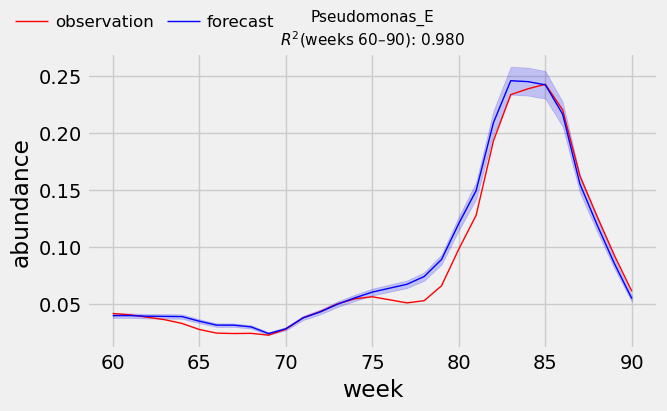

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# Explicitly specify the taxa to include
# selected_taxa = [
#     "Acidovorax", "Acinetobacter", "Aeromonas", "Aliarcobacter", "Giesbergeria",
#     "Ottowia", "Propionivibrio", "Pseudomonas_E", "Psychrobacter", "Tolumonas"
# ]
selected_taxa = [
 "Pseudomonas_E"
]
# Week vector
weeks = DF_data_smooth['week'] if 'week' in DF_data_smooth.columns else DF_data_smooth.index

# Subplot layout
ncols = 3
nrows = (len(selected_taxa) + ncols - 1) // ncols

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4 * nrows), constrained_layout=True)
axs = axs.flatten()

# Plotting loop
for i, taxon in enumerate(selected_taxa):
    ax = axs[i]

    obs = DF_data_smooth[taxon].values
    pred = DF_pop_smooth[taxon].values

    r2_all = r2_score(obs, pred)

    ax.plot(weeks, obs, label="observation", color="red", linewidth=1)
    ax.plot(weeks, pred, label="forecast", color="blue", linewidth=1)

    ax.fill_between(weeks, pred * 0.95, pred * 1.05, color="blue", alpha=0.2)

    ax.set_title(f"{taxon}\n$R^2$(weeks 60–90): {r2_all:.3f}", fontsize=11)
    ax.set_xlabel("week")
    ax.set_ylabel("abundance")

# Remove any unused axes
for j in range(len(selected_taxa), len(axs)):
    fig.delaxes(axs[j])

# Common legend
handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper left",
    ncol=2,
    fontsize=12,
    frameon=False,
    handletextpad=0.4,     # space between line and text
    columnspacing=0.8      # space between observation and forecast columns
)

plt.subplots_adjust(bottom=0.1)
plt.show()


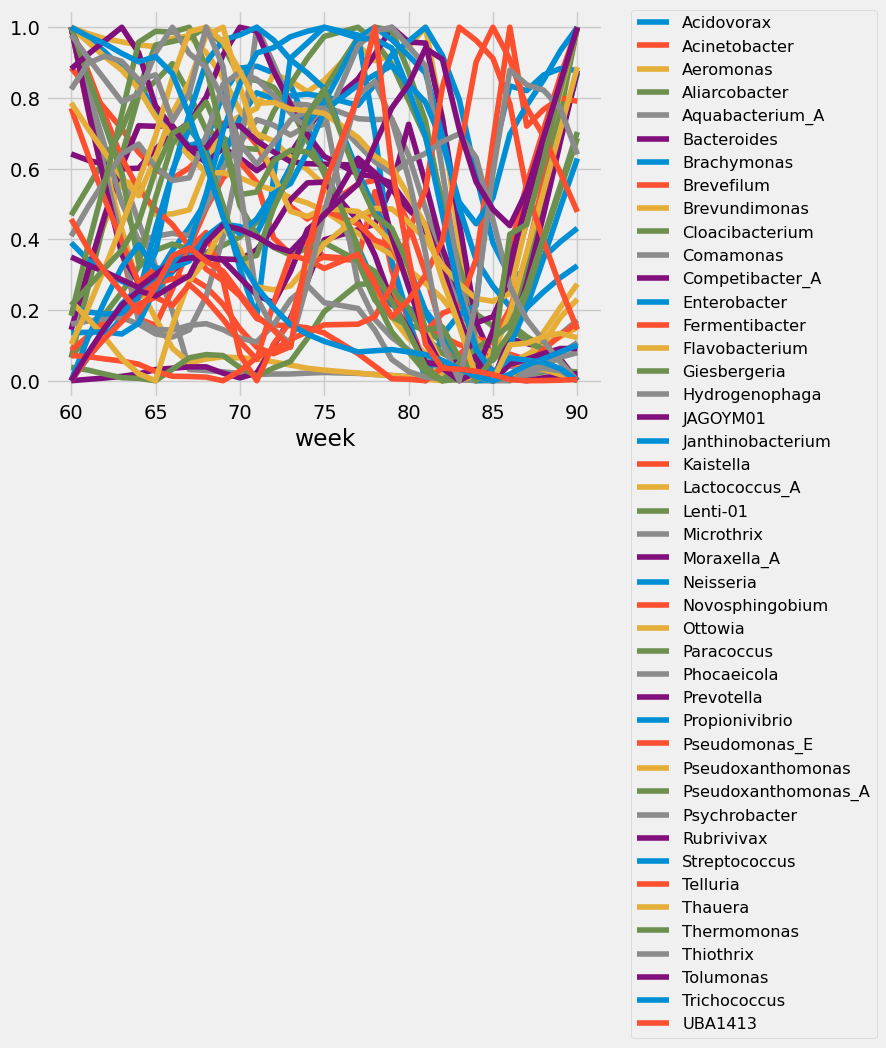

In [33]:
DF_pop = DF.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()
DF_data = data.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()

DF_pop_smooth = qsmooth(
    DF_pop,
    index="week",
    columns="variable",
    normalize=True,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.3,
)

# DF_data_smooth
DF_data_smooth = qsmooth(
    DF_data,
    index="week",
    columns="variable",
    normalize=True,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.3,
)

ax = DF_pop_smooth.plot(label="forecast")
# DF_data_smooth[biome].plot(ax=ax, label="observation")
ax.set_title(biome)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize='small', ncol=1)
plt.tight_layout()

In [286]:
test_df_grouped = (
    test_df
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)

In [288]:
test_df_smooth = qsmooth(
    test_df_grouped,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.4,
)


<Axes: xlabel='week'>

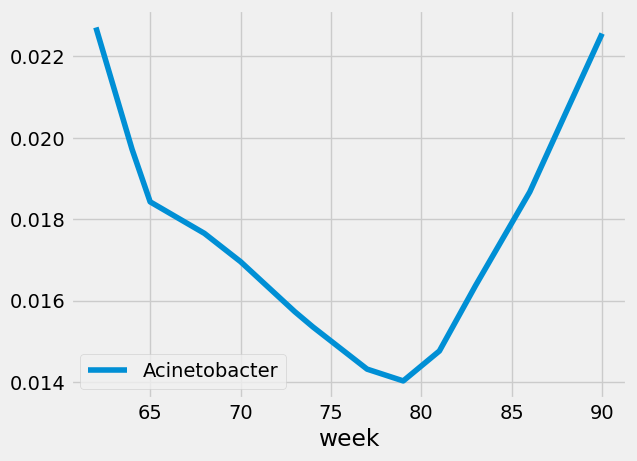

In [289]:
test_df_smooth.plot()

In [239]:
data[data.subject_id == SID]


,sample_id,subject_id,variable,value,week
4545,1014139_1,Rotterdam,Acidovorax,0.116992,62
4546,1014139_1,Rotterdam,Acinetobacter,0.024421,62
4547,1014139_1,Rotterdam,Aeromonas,0.011880,62
4548,1014139_1,Rotterdam,Aliarcobacter,0.014876,62
4549,1014139_1,Rotterdam,Aquabacterium_A,0.000422,62
...,...,...,...,...,...
5169,1014166_1,Rotterdam,Thermomonas,0.010926,90
5170,1014166_1,Rotterdam,Thiothrix,0.004042,90
5171,1014166_1,Rotterdam,Tolumonas,0.026276,90
5172,1014166_1,Rotterdam,Trichococcus,0.003335,90


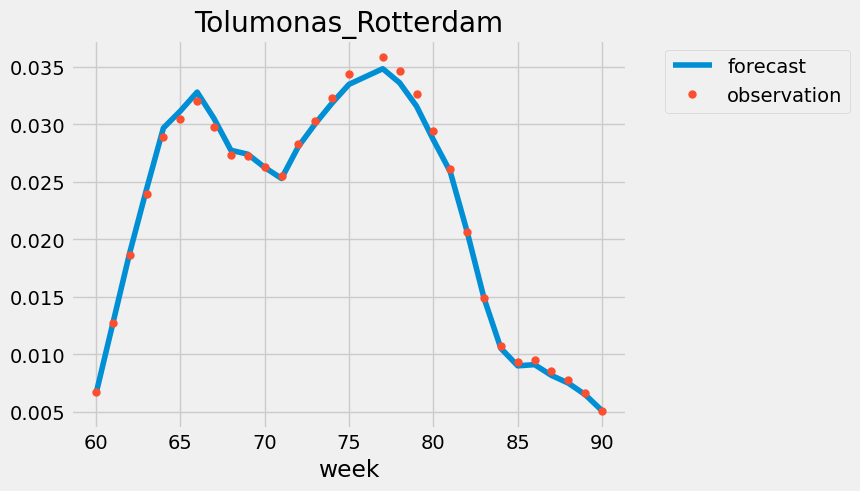

In [233]:
ax = DF_pop_smooth[var].plot(label="forecast")
DF_data_smooth[var].plot(ax=ax, style="o", ms=5, label="observation")
ax.set_title(biome +"_" +SID)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

In [84]:
DF.to_csv("forecasted-weeks-value.csv")

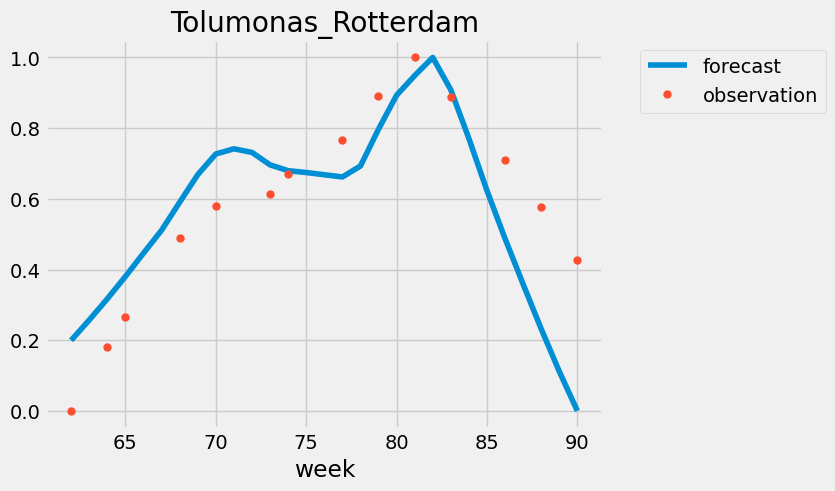

In [238]:
SID = "Rotterdam" #'Bologna', 'Budapest', 'Copenaghen_RA', 'Copenaghen_RD','Copenaghen_RL', 'Rome', 'Rotterdam']
DF_pop = (
    DF[DF.subject_id == SID]
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)
DF_data = (
    data[data.subject_id == SID]
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)
DF_pop_smooth = qsmooth(
    DF_pop,
    index="week",
    columns="variable",
    normalize=True,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.4,
)

# DF_data_smooth
DF_data_smooth = qsmooth(
    DF_data,
    index="week",
    columns="variable",
    normalize=True,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.6,
)

var = biome
ax = DF_pop_smooth[var].plot(label="forecast")
DF_data_smooth[var].plot(ax=ax, style="o", ms=5, label="observation")
ax.set_title(biome +"_" +SID)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

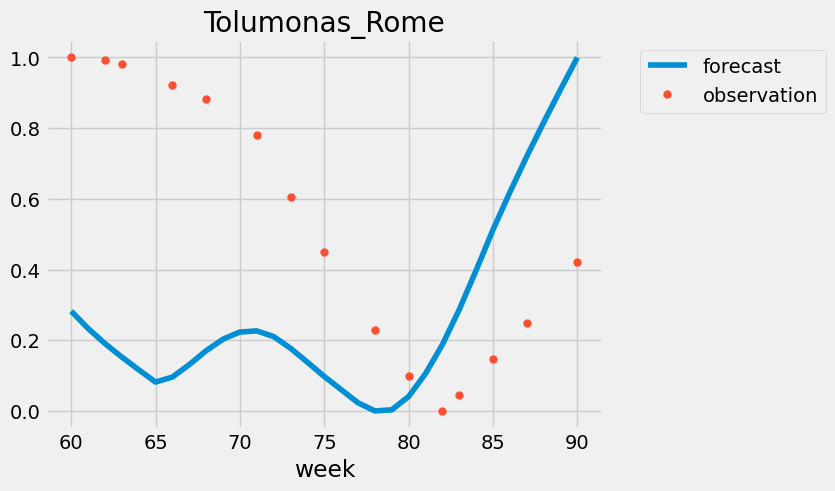

In [239]:
SID = "Rome" #'Bologna', 'Budapest', 'Copenaghen_RA', 'Copenaghen_RD','Copenaghen_RL', 'Rome', 'Rotterdam']
DF_pop = (
    DF[DF.subject_id == SID]
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)
DF_data = (
    data[data.subject_id == SID]
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)
DF_pop_smooth = qsmooth(
    DF_pop,
    index="week",
    columns="variable",
    normalize=True,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.4,
)

# DF_data_smooth
DF_data_smooth = qsmooth(
    DF_data,
    index="week",
    columns="variable",
    normalize=True,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.6,
)

var = biome
ax = DF_pop_smooth[var].plot(label="forecast")
DF_data_smooth[var].plot(ax=ax, style="o", ms=5, label="observation")
ax.set_title(biome +"_" +SID)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

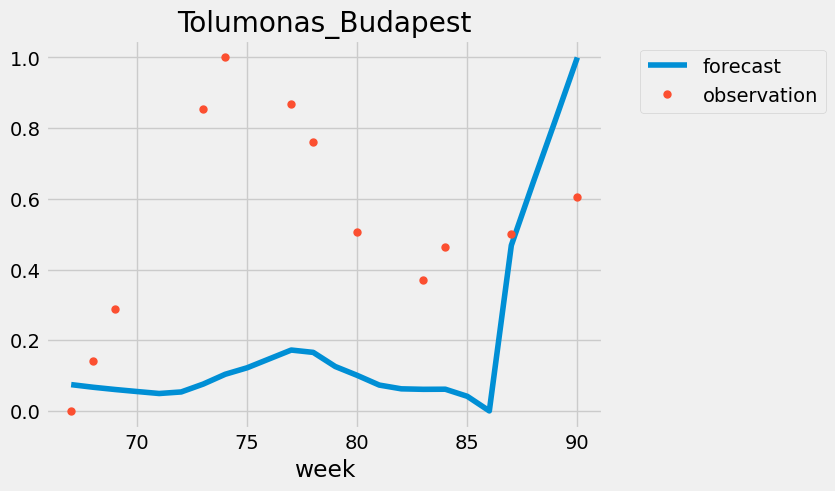

In [240]:
SID = "Budapest" #'Bologna', 'Budapest', 'Copenaghen_RA', 'Copenaghen_RD','Copenaghen_RL', 'Rome', 'Rotterdam']
DF_pop = (
    DF[DF.subject_id == SID]
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)
DF_data = (
    data[data.subject_id == SID]
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)
DF_pop_smooth = qsmooth(
    DF_pop,
    index="week",
    columns="variable",
    normalize=True,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.4,
)

# DF_data_smooth
DF_data_smooth = qsmooth(
    DF_data,
    index="week",
    columns="variable",
    normalize=True,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.6,
)

var = biome
ax = DF_pop_smooth[var].plot(label="forecast")
DF_data_smooth[var].plot(ax=ax, style="o", ms=5, label="observation")
ax.set_title(biome +"_" +SID)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

In [124]:
new_subject = DF[DF.subject_id == SID][["week","variable","value"]]
new_subject

,week,variable,value
5,60,Acidovorax,0.199114
12,61,Acidovorax,0.130982
19,62,Acidovorax,0.179373
26,63,Acidovorax,0.185913
33,64,Acidovorax,0.168911
...,...,...,...
9420,86,merged,0.327158
9427,87,merged,0.411606
9434,88,merged,0.460003
9441,89,merged,0.033917


In [236]:

new_subject_quantized = quantizer.quantize_new_subject(new_subject, subject_id=12345)
_, new_subject_matrix = quantizer.get_qnet_inputs(new_subject_quantized)
new_subject_forecasted = forecaster.forecast_data( 
    new_subject_matrix, start_week=SW+90, subject_id=["Bologna"], n_samples=50
)

df_ = qsmooth(
    new_subject_forecasted.drop("subject_id", axis=1),
    index="week",
    columns="variable",
    interpolate=False,
    alpha=0.5,
    lowess_fraction=0.3,
    normalize=True,
)


ax = df_[biome].plot()
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

NameError: name 'new_subject' is not defined

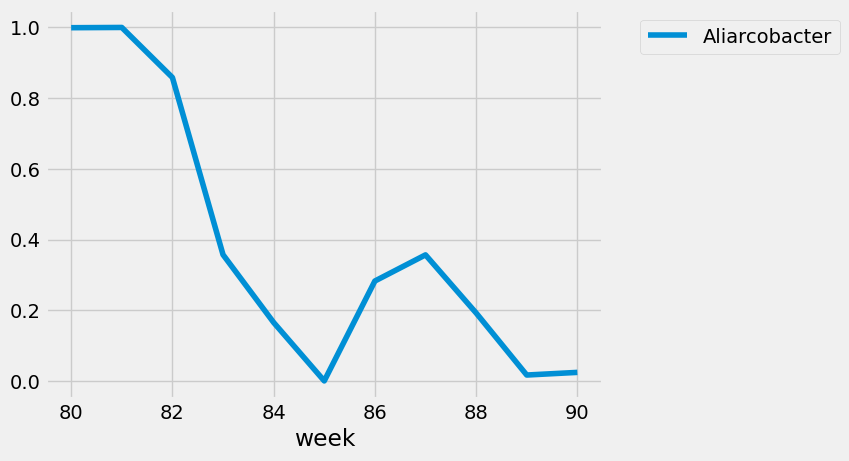

In [129]:
new_subject = pd.DataFrame(
    {
        "week": [60] * len(TAXA),
        "variable": TAXA,
        "value": np.random.rand(len(TAXA)),
    }
)


new_subject_quantized = quantizer.quantize_new_subject(new_subject, subject_id=SID)
_, new_subject_matrix = quantizer.get_qnet_inputs(new_subject_quantized)
new_subject_forecasted = forecaster.forecast_data( 
    new_subject_matrix, start_week=SW+20, subject_id=["Bologna"], n_samples=500
)

df_ = qsmooth(
    new_subject_forecasted.drop("subject_id", axis=1),
    index="week",
    columns="variable",
    interpolate=False,
    alpha=0.5,
    lowess_fraction=0.3,
    normalize=True,
)

ax = df_[biome].plot()
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

In [121]:
new_subject

,week,variable,value,subject_id
0,90,Acidovorax,0.684844,12345
1,90,Acinetobacter,0.865567,12345
2,90,Aeromonas,0.551120,12345
3,90,Aliarcobacter,0.055364,12345
4,90,Aquabacterium_A,0.224555,12345
5,90,Bacteroides,0.928987,12345
6,90,Brachymonas,0.880572,12345
7,90,Brevefilum,0.891120,12345
8,90,Brevundimonas,0.833107,12345
9,90,Cloacibacterium,0.372791,12345


### Generate Ecosystem Evolution for a Non-existant "Phantom" Patient

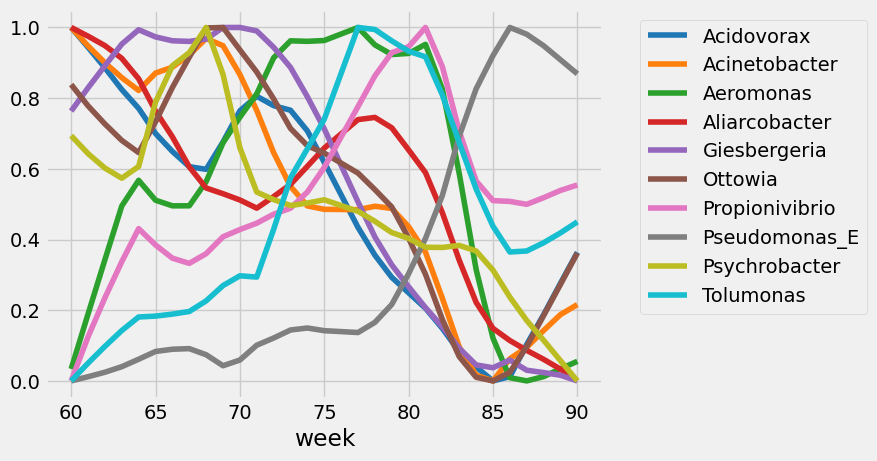

In [41]:
import pandas as pd
import numpy as np

# Define taxa list
TAXA = [
    "Acidovorax", "Acinetobacter", "Aeromonas", "Aliarcobacter", "Giesbergeria",
    "Ottowia", "Propionivibrio", "Pseudomonas_E", "Psychrobacter", "Tolumonas"
]

# Create new subject DataFrame
new_subject = pd.DataFrame({
    "week": [0] * len(TAXA),
    "variable": TAXA,
    "value": [np.nan] * len(TAXA),
})

# Run through quantizer and forecaster
new_subject_quantized = quantizer.quantize_new_subject(new_subject, subject_id=12345)
_, new_subject_matrix = quantizer.get_qnet_inputs(new_subject_quantized)
new_subject_forecasted = forecaster.forecast_data(
    new_subject_matrix, start_week=60, subject_id=[12345]
)

# Filter forecasted data by selected taxa
selected_taxa_new_subject = new_subject_forecasted[
    new_subject_forecasted['variable'].isin(TAXA)
]

# Apply qsmooth (assuming qsmooth is defined earlier)
df_ = qsmooth(
    selected_taxa_new_subject.drop("subject_id", axis=1),
    index="week",
    columns="variable",
    interpolate=False,
    alpha=0.5,
    lowess_fraction=0.3,
    normalize=True,
)

color_list = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
]
ax = df_.plot(color=color_list)
# # Plot
# ax = df_.plot()
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


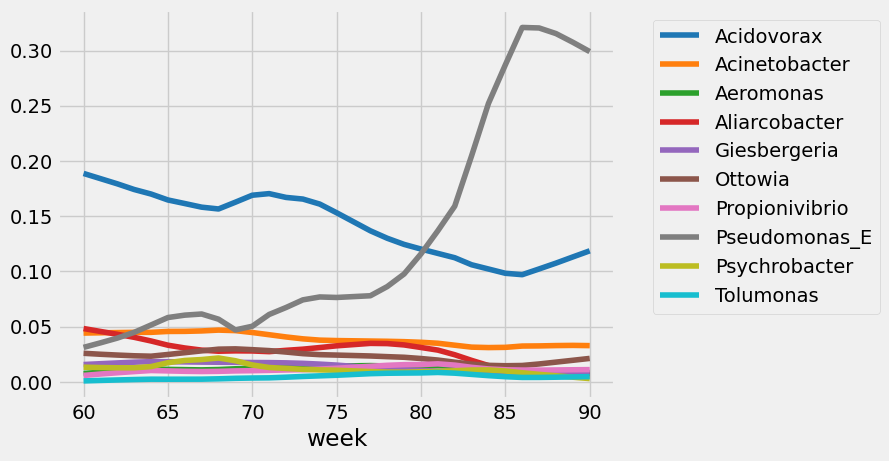

In [40]:
df_ = qsmooth(
    selected_taxa_new_subject.drop("subject_id", axis=1),
    index="week",
    columns="variable",
    interpolate=False,
    alpha=0.5,
    lowess_fraction=0.3,
    normalize=False,
)

color_list = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
]
ax = df_.plot(color=color_list)
# # Plot
# ax = df_.plot()
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


In [34]:
new_subject_forecasted

,subject_id,variable,week,value
0,12345,Acidovorax,60,NaN
1,12345,Acidovorax,61,NaN
2,12345,Acidovorax,62,NaN
3,12345,Acidovorax,63,NaN
4,12345,Acidovorax,64,NaN
...,...,...,...,...
1315,12345,UBA1413,86,1.294116e-04
1316,12345,UBA1413,87,1.121544e-06
1317,12345,UBA1413,88,8.658570e-07
1318,12345,UBA1413,89,5.786717e-08


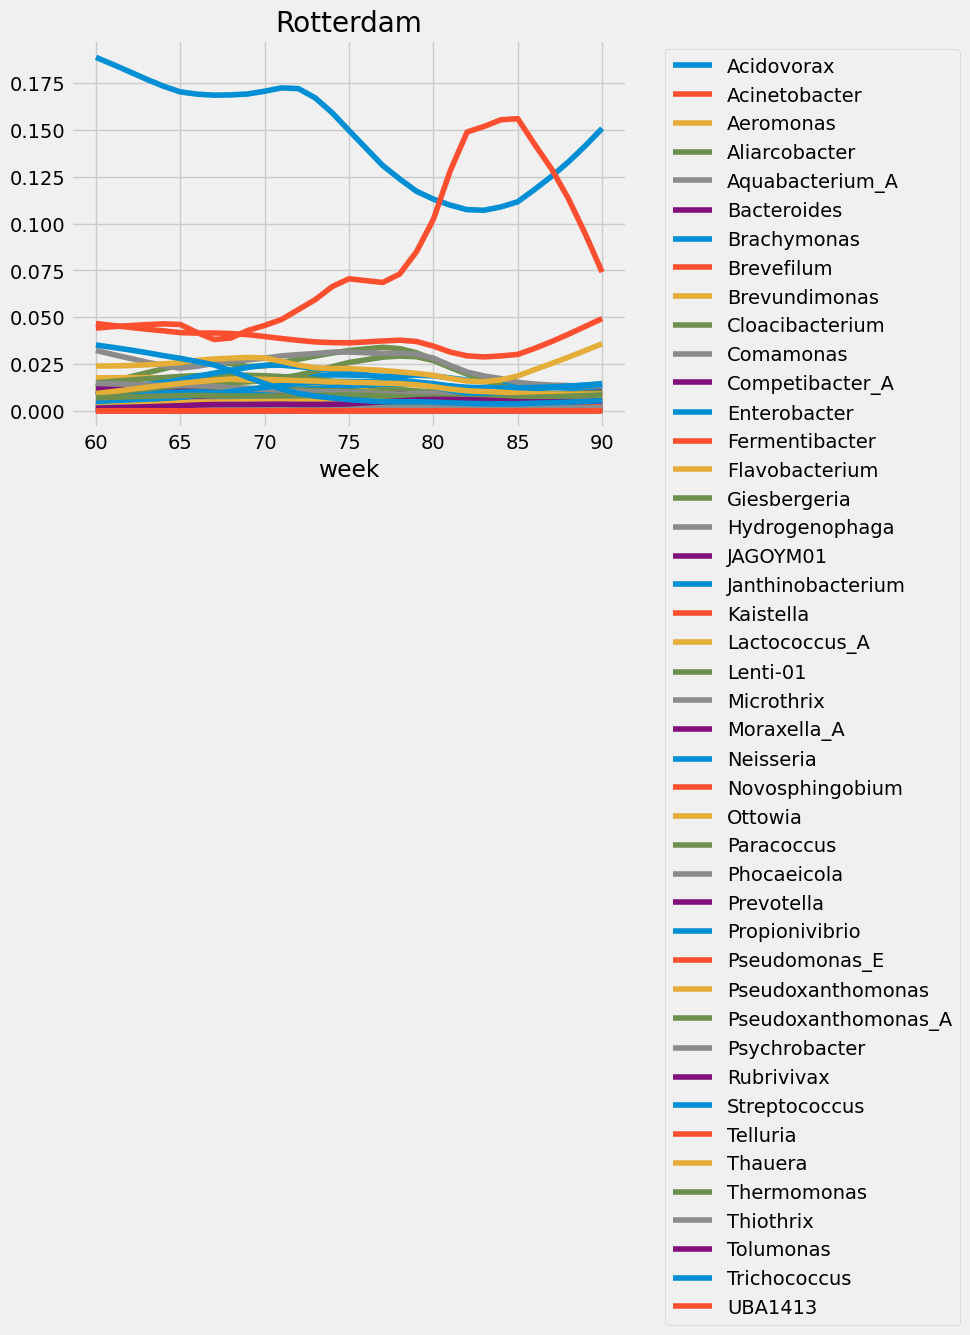

In [42]:
SID = "Rotterdam" #'Bologna', 'Budapest', 'Copenaghen_RA', 'Copenaghen_RD','Copenaghen_RL', 'Rome', 'Rotterdam']
DF_pop = (
    DF[DF.subject_id == SID]
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)
DF_data = (
    data[data.subject_id == SID]
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)
DF_pop_smooth = qsmooth(
    DF_pop,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.4,
)

# DF_data_smooth
DF_data_smooth = qsmooth(
    DF_data,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.6,
)

var = biome
ax = DF_pop_smooth.plot(label="forecast")
# DF_data_smooth[var].plot(ax=ax, style="o", ms=5, label="observation")
ax.set_title(SID)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")